In [ ]:
import time

import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, random_split, DataLoader

In [ ]:
from google.colab import drive
# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = ImageFolder('/content/drive/MyDrive/APS360/Project - Self/Final_dataset')
breeds = []

def rename(name):
    return ' '.join(' '.join(name.split('-')[1:]).split('_'))

for n in dataset.classes:
    breeds.append(rename(n))

Image Augmentation:


*   Random Flipping (Horizontally and/or Vertically depending on image)
*   Random Rotation
*   Random Zooming
*   Random Shearing
*   Random Adjustment of Brightness









In [ ]:
#Define the class
class DogBreedDataset(Dataset):
    
    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform
        
    def __len__(self):
        return len(self.ds)
    
    def __getitem__(self, idx):
        img, label = self.ds[idx]
        if self.transform:
            img = self.transform(img)  
            return img, label

In [ ]:
#Split Train/Valid/Test Dataset
#0.8,0.1,0.1
random_seed = 45
torch.manual_seed(random_seed);
test_pct = 0.10
test_size = int(len(dataset)*test_pct)

val_size = test_size
train_size =int(len(dataset)-val_size-test_size)
train_size, val_size, test_size, len(dataset)
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(train_ds), len(val_ds), len(test_ds)

# val_size = int(len(dataset)*0.2)
# train_size =int(len(dataset)-val_size)
# train_size, val_size, test_size, len(dataset)
# train_ds, val_ds= random_split(dataset, [train_size, val_size])
# len(train_ds), len(val_ds)

(5507, 688, 688)

In [ ]:
# #@title
# #find mean and std of the train set
# first_transform = transforms.Compose([transforms.Resize((256,256)),transforms.RandomCrop((224,224)),transforms.ToTensor()]);
# train_dataset = DogBreedDataset(train_ds, first_transform)
# batch_size = 2
# train_dl = DataLoader(train_dataset, batch_size=batch_size, num_workers=1)
# def batch_mean_and_sd(loader):
    
#     cnt = 0
#     fst_moment = torch.empty(3)
#     snd_moment = torch.empty(3)

#     for images, _ in loader:
#         b, c, h, w = images.shape
#         nb_pixels = b * h * w
#         sum_ = torch.sum(images, dim=[0, 2, 3])
#         sum_of_square = torch.sum(images ** 2,
#                                   dim=[0, 2, 3])
#         fst_moment = (cnt * fst_moment + sum_) / (
#                       cnt + nb_pixels)
#         snd_moment = (cnt * snd_moment + sum_of_square) / (
#                             cnt + nb_pixels)
#         cnt += nb_pixels

#     mean, std = fst_moment, torch.sqrt(
#       snd_moment - fst_moment ** 2)        
#     return mean,std
  
# mean, std = batch_mean_and_sd(train_dl)
# print("mean and std: \n", mean, std)

In [ ]:
#mean and std for the train set:
# 0.7,0.15,0.15:
mean = torch.tensor([0.4741, 0.4431,0.3861])
std = torch.tensor([0.2583, 0.2524, 0.2585])

#0.8,0.1,0.1:
mean80 = torch.tensor([0.4743, 0.4438, 0.3871]);
std80 = torch.tensor([0.2576, 0.2520, 0.2585])
#0.9, 0.1
mean90 = torch.tensor([0.4742, 0.4437, 0.3869]) 
std90 = torch.tensor([0.2576, 0.2520, 0.2584])
#0.85, 0.15
mean85 = torch.tensor([0.4741, 0.4438, 0.3872]) 
std85 = torch.tensor([0.2575, 0.2520, 0.2584])

#0.8,0.2
mean8020 = torch.tensor([0.4743, 0.4438, 0.3870]) 
std8020 = torch.tensor([0.2576, 0.2520, 0.2585])


In [ ]:
#Data Augmentation :https://towardsdatascience.com/data-augmentations-in-torchvision-5d56d70c372e
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean8020, std8020),
    transforms.RandomErasing()
    
])


val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

])

test_transform = transforms.Compose([
    transforms.Resize((224,224)), 
    transforms.ToTensor(),
])

In [ ]:
#Create data sets
train_dataset = DogBreedDataset(train_ds, train_transform)
val_dataset = DogBreedDataset(val_ds, val_transform)
test_dataset = DogBreedDataset(test_ds, test_transform)

In [ ]:
# #Maybe move to training loop ?
# batch_size =64
# # Create DataLoaders
# train_dl = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
# val_dl = DataLoader(val_dataset, batch_size*2, num_workers=2, pin_memory=True)
# test_dl = DataLoader(test_dataset, batch_size*2, num_workers=2, pin_memory=True)

In [ ]:
# def show_batch(dl):
#     for img, lb in dl:
#         fig, ax = plt.subplots(figsize=(16, 8))
#         ax.set_xticks([]); ax.set_yticks([])
#         ax.imshow(make_grid(img.cpu(), nrow=16).permute(1,2,0))
#         break
# show_batch(train_dl)

In [ ]:
#Switching To GPU https://www.analyticsvidhya.com/blog/2021/05/a-complete-hands-on-guide-to-train-your-neural-network-model-on-google-colab-gpu/
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(d, device) for d in data]
    else:
        return data.to(device, non_blocking=True)
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    
    def __len__(self):
        return len(self.dl)
    
    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

In [ ]:
# getting default device
device = get_default_device()
print(device)

cuda


In [ ]:
class CNN_6(nn.Module):
    def __init__(self):
        super(CNN_6, self).__init__()
        self.name = "CNN_6" 

        self.conv1 = nn.Conv2d(3, 30, 3)
        self.norm1 = nn.BatchNorm2d(30) 
        self.conv2 = nn.Conv2d(30, 30, 3)
        self.norm2 = nn.BatchNorm2d(30) 

        self.conv3 = nn.Conv2d(30, 60, 3)
        self.norm3 = nn.BatchNorm2d(60) 
        self.conv4 = nn.Conv2d(60, 60, 3) 
        self.norm4 = nn.BatchNorm2d(60)  

        self.conv5 = nn.Conv2d(60, 120, 3) 
        self.norm5 = nn.BatchNorm2d(120) 
        self.conv6 = nn.Conv2d(120, 120, 3) 
        self.norm6 = nn.BatchNorm2d(120)

        self.fc1 = nn.Linear(120, 80)
        self.fc2 = nn.Linear(80, 40)

        self.pool = nn.MaxPool2d(2, 2)
        self.do1 = nn.Dropout(0.1)

    def forward(self, x):
        x = self.pool(F.relu(self.norm1(self.conv1(x)))) # o=111
        x = self.pool(F.relu(self.norm2(self.conv2(x)))) # o=54
        #x = self.do1(x)

        x = self.pool(F.relu(self.norm3(self.conv3(x)))) # o=26
        x = self.pool(F.relu(self.norm4(self.conv4(x)))) # o=12
        #x = self.do1(x)

        x = self.pool(F.relu(self.norm5(self.conv5(x)))) # o=5
        x = self.pool(F.relu(self.norm6(self.conv6(x)))) # o=1
        x = self.do1(x)

        x = x.view(-1, 120) # 120*1^2 = 120

        x = F.relu(self.fc1(x))
        x = self.do1(x)
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]

        return x

    print('Convolutional Neural Network Architecture Done')

Convolutional Neural Network Architecture Done


In [ ]:
def get_accuracy(model,data):
    correct = 0
    total = 0
    for imgs, labels in data:
         #############################################
        #To Enable GPU Usage
        if torch.cuda.is_available():
          imgs = imgs.cuda()
          labels = labels.cuda()
        #############################################
        output = model(imgs)
        
        #select index with maximum prediction score
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
    return correct / total

def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

In [ ]:
#Define the Training Loop 

def train(model, train_dataset,valid_dataset,batch_size=64, num_epochs=1,learningRate=0.01, weight_decay=0.001):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    valid_loader=DataLoader(valid_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    #Moving To GPU 
    train_dl_GPU = DeviceDataLoader(train_loader, device)
    val_dl_GPU = DeviceDataLoader(valid_loader, device)
    to_device(model, device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learningRate, weight_decay=weight_decay)
    losses, train_acc, val_acc = [], [], []
    # training
    #totalLoss=0
    start_time = time.time()
    for epoch in range(num_epochs):
        totalLoss=0
        #loopCount = 0;
        for i,data in enumerate(train_dl_GPU):
            imgs,labels=data
            #To Enable GPU Usage
            if torch.cuda.is_available():
              imgs = imgs.cuda()
              labels = labels.cuda()

            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch
            totalLoss+=loss.item()

        losses.append(float(totalLoss)/len(train_ds))             # compute *average* loss
        train_acc.append(get_accuracy(model,train_dl_GPU)) # compute training accuracy 
        val_acc.append(get_accuracy(model,val_dl_GPU))  # compute validation accuracy
        cur_time = time.time()
        cur_e_time = (cur_time - start_time)/60
        print("Epoch: {}, Train Accuracy: {:.6f}, Validation Accuracy: {:.6f}, Time: {:.2f} minutes"
              .format(epoch+1, train_acc[-1], val_acc[-1], cur_e_time))

    iters=len(losses)
    # plotting
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    plt.title("Training Curve")
    plt.plot(losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Training Accuracy")
    plt.legend(loc='best')
    plt.show()

    print("Final Training Accuracy: {}".format(train_acc[-1]))
    print("Final Validation Accuracy: {}".format(val_acc[-1]))
    print("Best Training Accuracy: {}".format(max(train_acc)))
    print("Best Validation Accuracy: {}".format(max(val_acc)))
    return out, labels


Training on GPU
Training
Epoch: 1, Train Accuracy: 0.093517, Validation Accuracy: 0.090116, Time: 37.71 minutes
Epoch: 2, Train Accuracy: 0.117668, Validation Accuracy: 0.094477, Time: 39.14 minutes
Epoch: 3, Train Accuracy: 0.134738, Validation Accuracy: 0.122093, Time: 40.57 minutes
Epoch: 4, Train Accuracy: 0.144362, Validation Accuracy: 0.145349, Time: 41.99 minutes
Epoch: 5, Train Accuracy: 0.162520, Validation Accuracy: 0.167151, Time: 43.42 minutes
Epoch: 6, Train Accuracy: 0.180679, Validation Accuracy: 0.187500, Time: 44.85 minutes
Epoch: 7, Train Accuracy: 0.181587, Validation Accuracy: 0.177326, Time: 46.32 minutes
Epoch: 8, Train Accuracy: 0.201925, Validation Accuracy: 0.207849, Time: 47.74 minutes
Epoch: 9, Train Accuracy: 0.207736, Validation Accuracy: 0.206395, Time: 49.17 minutes
Epoch: 10, Train Accuracy: 0.211731, Validation Accuracy: 0.218023, Time: 50.60 minutes
Epoch: 11, Train Accuracy: 0.222807, Validation Accuracy: 0.226744, Time: 52.04 minutes
Epoch: 12, Train

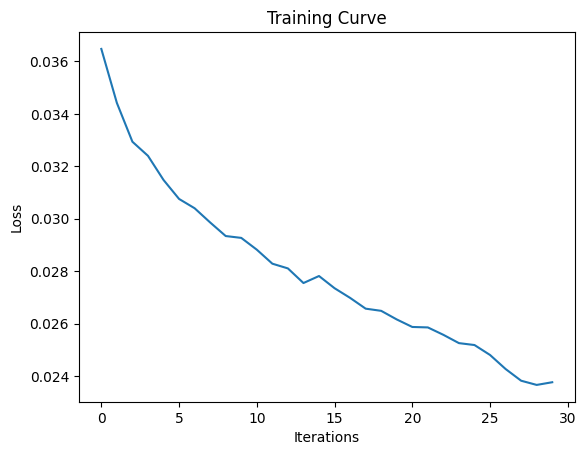

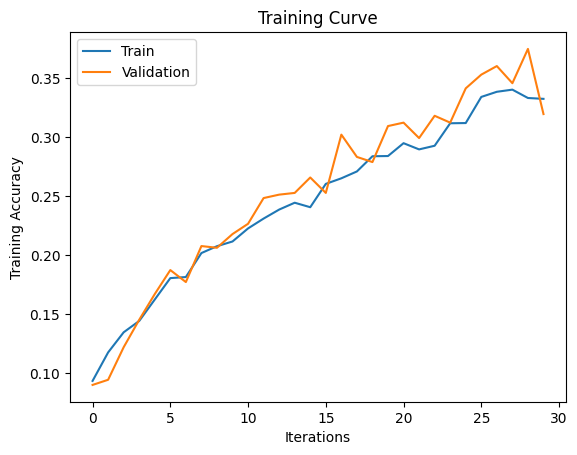

Final Training Accuracy: 0.332667514072998
Final Validation Accuracy: 0.31976744186046513
Correct Labels
tensor([ 5, 35,  1, 39, 15,  7,  7], device='cuda:0')
Predicted Labels
[tensor(5), tensor(24), tensor(1), tensor(38), tensor(14), tensor(35), tensor(37)]
Testing


0.3125

In [ ]:
model=CNN_6()

epoch_n = 30

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda() 
  print("Training on GPU")

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 30 E

Training
Epoch: 1, Train Accuracy: 0.366624, Validation Accuracy: 0.385174, Time: 1.42 minutes
Epoch: 2, Train Accuracy: 0.375885, Validation Accuracy: 0.393895, Time: 2.84 minutes
Epoch: 3, Train Accuracy: 0.379699, Validation Accuracy: 0.379360, Time: 4.27 minutes
Epoch: 4, Train Accuracy: 0.376612, Validation Accuracy: 0.395349, Time: 5.69 minutes
Epoch: 5, Train Accuracy: 0.385509, Validation Accuracy: 0.369186, Time: 7.18 minutes
Epoch: 6, Train Accuracy: 0.374069, Validation Accuracy: 0.380814, Time: 8.60 minutes
Epoch: 7, Train Accuracy: 0.384238, Validation Accuracy: 0.373547, Time: 10.02 minutes
Epoch: 8, Train Accuracy: 0.399310, Validation Accuracy: 0.418605, Time: 11.45 minutes
Epoch: 9, Train Accuracy: 0.398584, Validation Accuracy: 0.404070, Time: 12.90 minutes
Epoch: 10, Train Accuracy: 0.414563, Validation Accuracy: 0.406977, Time: 14.36 minutes
Epoch: 11, Train Accuracy: 0.415290, Validation Accuracy: 0.415698, Time: 15.80 minutes
Epoch: 12, Train Accuracy: 0.422190, V

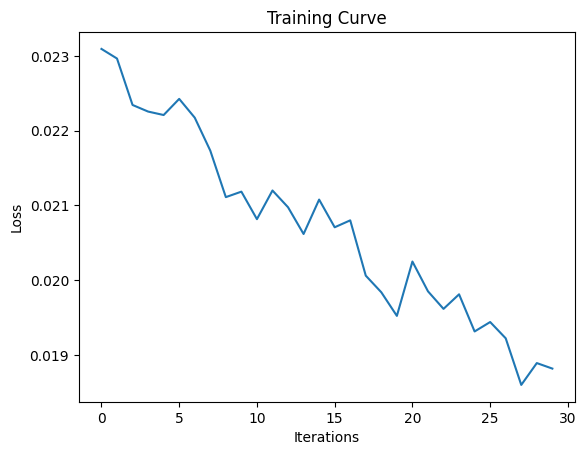

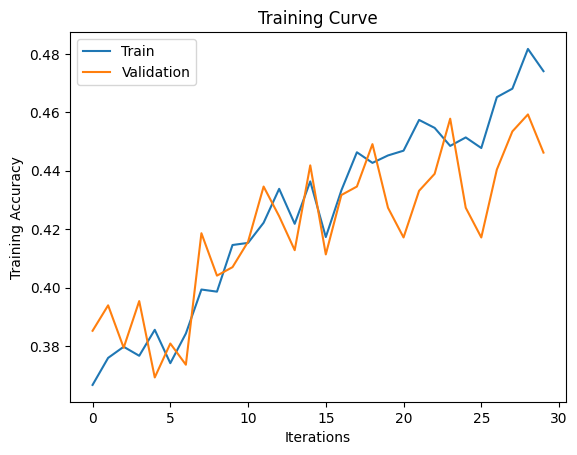

Final Training Accuracy: 0.4741238423824224
Final Validation Accuracy: 0.44622093023255816
Correct Labels
tensor([ 9,  9, 35,  0, 38,  1, 34], device='cuda:0')
Predicted Labels
[tensor(24), tensor(27), tensor(35), tensor(0), tensor(38), tensor(7), tensor(15)]
Testing


0.40988372093023256

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

# 60 E

Training
Epoch: 1, Train Accuracy: 0.477756, Validation Accuracy: 0.465116, Time: 1.45 minutes
Epoch: 2, Train Accuracy: 0.477756, Validation Accuracy: 0.443314, Time: 2.91 minutes
Epoch: 3, Train Accuracy: 0.486472, Validation Accuracy: 0.469477, Time: 4.38 minutes
Epoch: 4, Train Accuracy: 0.493372, Validation Accuracy: 0.465116, Time: 5.84 minutes
Epoch: 5, Train Accuracy: 0.497185, Validation Accuracy: 0.465116, Time: 7.30 minutes
Epoch: 6, Train Accuracy: 0.493917, Validation Accuracy: 0.454942, Time: 8.75 minutes
Epoch: 7, Train Accuracy: 0.518613, Validation Accuracy: 0.465116, Time: 10.22 minutes
Epoch: 8, Train Accuracy: 0.510078, Validation Accuracy: 0.462209, Time: 11.68 minutes
Epoch: 9, Train Accuracy: 0.501180, Validation Accuracy: 0.466570, Time: 13.13 minutes
Epoch: 10, Train Accuracy: 0.493372, Validation Accuracy: 0.469477, Time: 14.61 minutes
Epoch: 11, Train Accuracy: 0.494825, Validation Accuracy: 0.472384, Time: 16.09 minutes
Epoch: 12, Train Accuracy: 0.497730, V

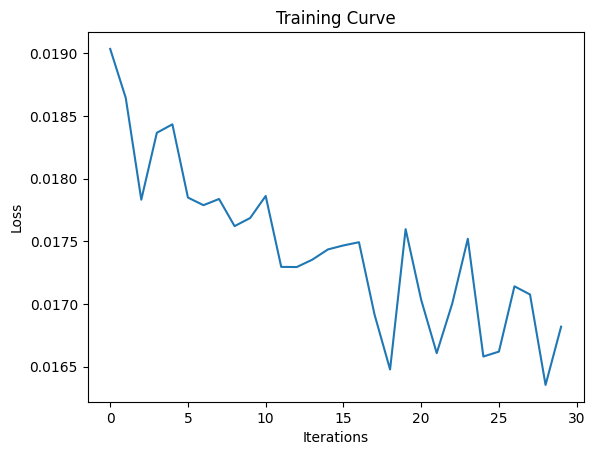

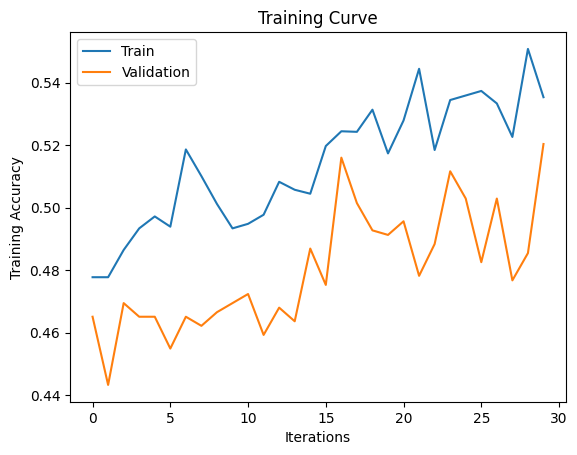

Final Training Accuracy: 0.5353186853096059
Final Validation Accuracy: 0.5203488372093024
Correct Labels
tensor([19, 28, 17, 16, 33, 22,  1], device='cuda:0')
Predicted Labels
[tensor(3), tensor(4), tensor(18), tensor(27), tensor(33), tensor(8), tensor(1)]
Testing


0.4622093023255814

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

# 90 E

Training
Epoch: 1, Train Accuracy: 0.536227, Validation Accuracy: 0.498547, Time: 1.54 minutes
Epoch: 2, Train Accuracy: 0.546940, Validation Accuracy: 0.510174, Time: 3.05 minutes
Epoch: 3, Train Accuracy: 0.539314, Validation Accuracy: 0.481105, Time: 4.51 minutes
Epoch: 4, Train Accuracy: 0.540040, Validation Accuracy: 0.488372, Time: 5.99 minutes
Epoch: 5, Train Accuracy: 0.548030, Validation Accuracy: 0.504360, Time: 7.45 minutes
Epoch: 6, Train Accuracy: 0.555838, Validation Accuracy: 0.514535, Time: 8.91 minutes
Epoch: 7, Train Accuracy: 0.547303, Validation Accuracy: 0.489826, Time: 10.39 minutes
Epoch: 8, Train Accuracy: 0.544580, Validation Accuracy: 0.492733, Time: 11.85 minutes
Epoch: 9, Train Accuracy: 0.555475, Validation Accuracy: 0.520349, Time: 13.30 minutes
Epoch: 10, Train Accuracy: 0.547667, Validation Accuracy: 0.498547, Time: 14.79 minutes
Epoch: 11, Train Accuracy: 0.562194, Validation Accuracy: 0.476744, Time: 16.26 minutes
Epoch: 12, Train Accuracy: 0.560378, V

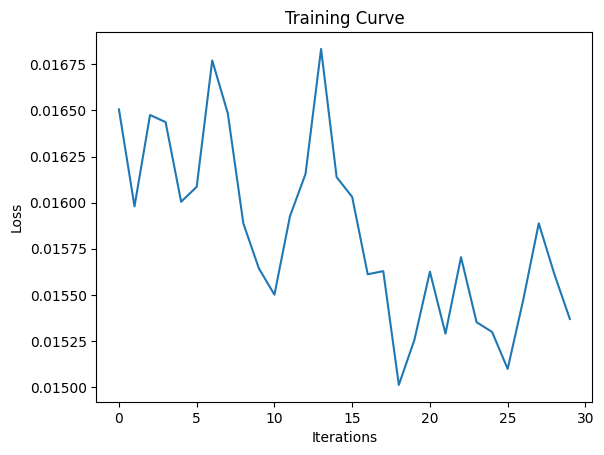

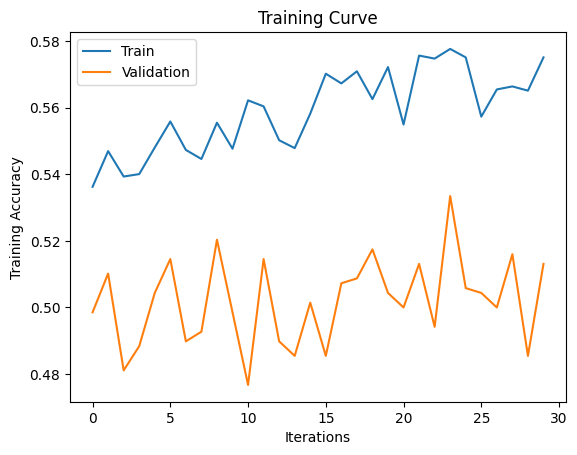

Final Training Accuracy: 0.5750862538587252
Final Validation Accuracy: 0.5130813953488372
Correct Labels
tensor([35, 21, 29, 23, 25, 36, 18], device='cuda:0')
Predicted Labels
[tensor(35), tensor(21), tensor(0), tensor(23), tensor(8), tensor(36), tensor(18)]
Testing


0.4898255813953488

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 120 E

In [ ]:
model=CNN_6()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda() 
  print("Training on GPU")

transfer_state = torch.load("/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/model_0406_CNN_6_bs100_lr0.001_epoch120")
model.load_state_dict(transfer_state)

Training on GPU


<All keys matched successfully>

Training
Epoch: 1, Train Accuracy: 0.552751, Validation Accuracy: 0.482558, Time: 23.13 minutes
Epoch: 2, Train Accuracy: 0.572181, Validation Accuracy: 0.489826, Time: 24.70 minutes
Epoch: 3, Train Accuracy: 0.580715, Validation Accuracy: 0.524709, Time: 26.24 minutes
Epoch: 4, Train Accuracy: 0.571091, Validation Accuracy: 0.513081, Time: 27.80 minutes
Epoch: 5, Train Accuracy: 0.566188, Validation Accuracy: 0.486919, Time: 29.36 minutes
Epoch: 6, Train Accuracy: 0.582531, Validation Accuracy: 0.498547, Time: 30.92 minutes
Epoch: 7, Train Accuracy: 0.582531, Validation Accuracy: 0.518895, Time: 32.46 minutes
Epoch: 8, Train Accuracy: 0.572181, Validation Accuracy: 0.504360, Time: 33.99 minutes
Epoch: 9, Train Accuracy: 0.588524, Validation Accuracy: 0.500000, Time: 35.52 minutes
Epoch: 10, Train Accuracy: 0.582713, Validation Accuracy: 0.524709, Time: 37.08 minutes
Epoch: 11, Train Accuracy: 0.587616, Validation Accuracy: 0.537791, Time: 38.60 minutes
Epoch: 12, Train Accuracy: 0.586

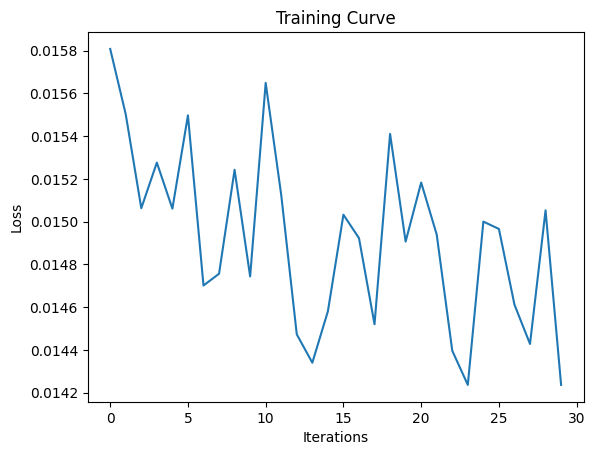

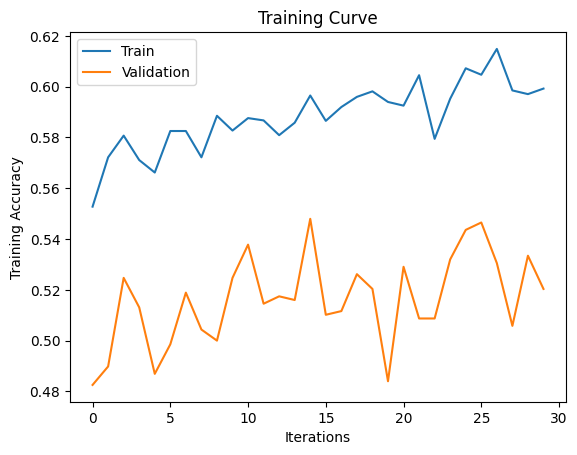

Final Training Accuracy: 0.5992373343017977
Final Validation Accuracy: 0.5203488372093024
Correct Labels
tensor([ 5, 35,  1, 39, 15,  7,  7], device='cuda:0')
Predicted Labels
[tensor(5), tensor(39), tensor(1), tensor(23), tensor(16), tensor(34), tensor(25)]
Testing


0.501453488372093

In [ ]:
epoch_n = 150

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 150 E

Training
Epoch: 1, Train Accuracy: 0.588705, Validation Accuracy: 0.515988, Time: 1.56 minutes
Epoch: 2, Train Accuracy: 0.601053, Validation Accuracy: 0.539244, Time: 3.09 minutes
Epoch: 3, Train Accuracy: 0.598329, Validation Accuracy: 0.521802, Time: 4.63 minutes
Epoch: 4, Train Accuracy: 0.609043, Validation Accuracy: 0.540698, Time: 6.18 minutes
Epoch: 5, Train Accuracy: 0.586526, Validation Accuracy: 0.514535, Time: 7.75 minutes
Epoch: 6, Train Accuracy: 0.597240, Validation Accuracy: 0.507267, Time: 9.30 minutes
Epoch: 7, Train Accuracy: 0.594516, Validation Accuracy: 0.511628, Time: 10.85 minutes
Epoch: 8, Train Accuracy: 0.609406, Validation Accuracy: 0.530523, Time: 12.39 minutes
Epoch: 9, Train Accuracy: 0.614309, Validation Accuracy: 0.537791, Time: 13.94 minutes
Epoch: 10, Train Accuracy: 0.604867, Validation Accuracy: 0.495640, Time: 15.48 minutes
Epoch: 11, Train Accuracy: 0.616488, Validation Accuracy: 0.536337, Time: 17.07 minutes
Epoch: 12, Train Accuracy: 0.621028, V

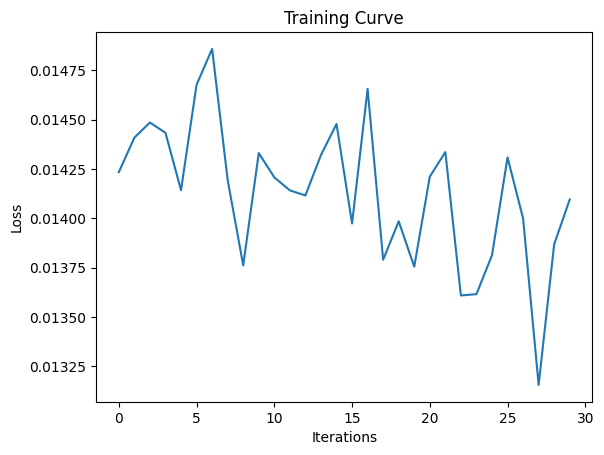

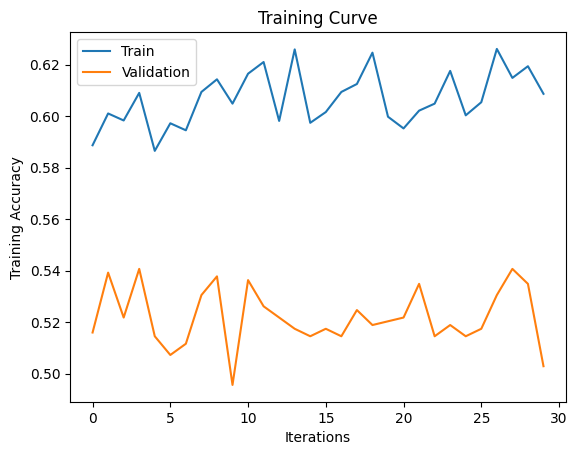

Final Training Accuracy: 0.6086798619938261
Final Validation Accuracy: 0.502906976744186
Correct Labels
tensor([ 9,  9, 35,  0, 38,  1, 34], device='cuda:0')
Predicted Labels
[tensor(24), tensor(32), tensor(35), tensor(0), tensor(38), tensor(12), tensor(15)]
Testing


0.4898255813953488

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 180 E

Training
Epoch: 1, Train Accuracy: 0.584166, Validation Accuracy: 0.526163, Time: 1.53 minutes
Epoch: 2, Train Accuracy: 0.608861, Validation Accuracy: 0.531977, Time: 3.04 minutes
Epoch: 3, Train Accuracy: 0.621573, Validation Accuracy: 0.561047, Time: 4.58 minutes
Epoch: 4, Train Accuracy: 0.616125, Validation Accuracy: 0.494186, Time: 6.08 minutes
Epoch: 5, Train Accuracy: 0.617941, Validation Accuracy: 0.518895, Time: 7.60 minutes
Epoch: 6, Train Accuracy: 0.617033, Validation Accuracy: 0.531977, Time: 9.10 minutes
Epoch: 7, Train Accuracy: 0.634647, Validation Accuracy: 0.533430, Time: 10.60 minutes
Epoch: 8, Train Accuracy: 0.621209, Validation Accuracy: 0.537791, Time: 12.13 minutes
Epoch: 9, Train Accuracy: 0.615035, Validation Accuracy: 0.524709, Time: 13.63 minutes
Epoch: 10, Train Accuracy: 0.619030, Validation Accuracy: 0.529070, Time: 15.14 minutes
Epoch: 11, Train Accuracy: 0.611585, Validation Accuracy: 0.526163, Time: 16.67 minutes
Epoch: 12, Train Accuracy: 0.607227, V

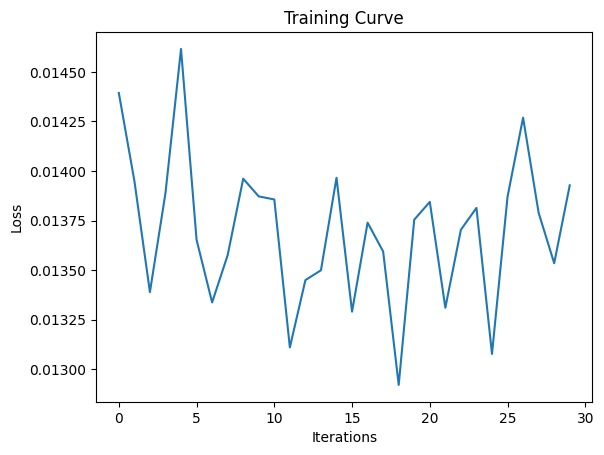

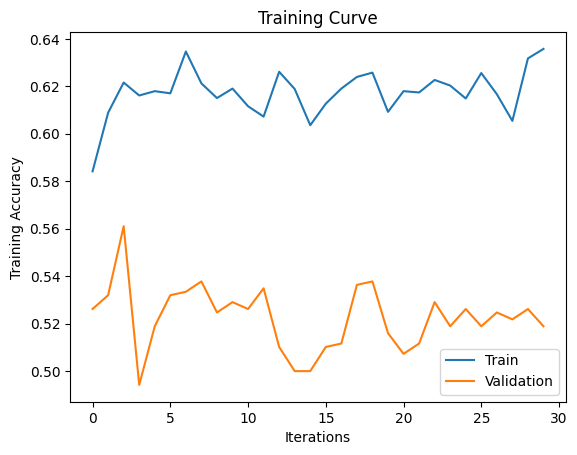

Final Training Accuracy: 0.6357363355729072
Final Validation Accuracy: 0.5188953488372093
Correct Labels
tensor([19, 28, 17, 16, 33, 22,  1], device='cuda:0')
Predicted Labels
[tensor(4), tensor(27), tensor(19), tensor(27), tensor(33), tensor(37), tensor(1)]
Testing


0.5087209302325582

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 210 E

Training
Epoch: 1, Train Accuracy: 0.622299, Validation Accuracy: 0.515988, Time: 1.53 minutes
Epoch: 2, Train Accuracy: 0.629926, Validation Accuracy: 0.539244, Time: 3.07 minutes
Epoch: 3, Train Accuracy: 0.619757, Validation Accuracy: 0.515988, Time: 4.61 minutes
Epoch: 4, Train Accuracy: 0.630470, Validation Accuracy: 0.534884, Time: 6.15 minutes
Epoch: 5, Train Accuracy: 0.627020, Validation Accuracy: 0.534884, Time: 7.69 minutes
Epoch: 6, Train Accuracy: 0.633376, Validation Accuracy: 0.539244, Time: 9.24 minutes
Epoch: 7, Train Accuracy: 0.632468, Validation Accuracy: 0.531977, Time: 10.78 minutes
Epoch: 8, Train Accuracy: 0.628110, Validation Accuracy: 0.546512, Time: 12.32 minutes
Epoch: 9, Train Accuracy: 0.623752, Validation Accuracy: 0.534884, Time: 13.83 minutes
Epoch: 10, Train Accuracy: 0.628110, Validation Accuracy: 0.523256, Time: 15.37 minutes
Epoch: 11, Train Accuracy: 0.631378, Validation Accuracy: 0.500000, Time: 16.91 minutes
Epoch: 12, Train Accuracy: 0.625931, V

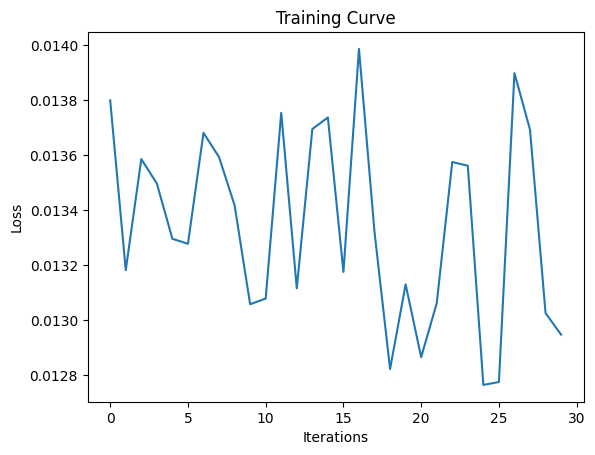

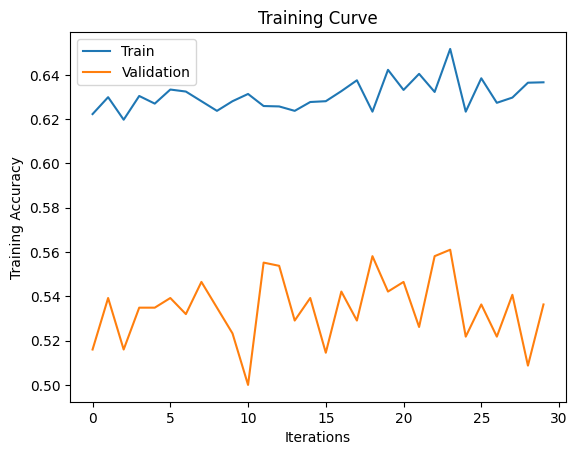

Final Training Accuracy: 0.63664427092791
Final Validation Accuracy: 0.5363372093023255
Correct Labels
tensor([35, 21, 29, 23, 25, 36, 18], device='cuda:0')
Predicted Labels
[tensor(35), tensor(26), tensor(3), tensor(23), tensor(25), tensor(36), tensor(18)]
Testing


0.5290697674418605

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 240 E

In [ ]:
model=CNN_6()

epoch_n = 240

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda() 
  print("Training on GPU")

transfer_state = torch.load("/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/model_0406_CNN_6_bs100_lr0.001_epoch240")
model.load_state_dict(transfer_state)

Training on GPU


<All keys matched successfully>

Training
Epoch: 1, Train Accuracy: 0.635736, Validation Accuracy: 0.533430, Time: 11.57 minutes
Epoch: 2, Train Accuracy: 0.631741, Validation Accuracy: 0.523256, Time: 12.97 minutes
Epoch: 3, Train Accuracy: 0.644997, Validation Accuracy: 0.514535, Time: 14.38 minutes
Epoch: 4, Train Accuracy: 0.637734, Validation Accuracy: 0.547965, Time: 15.79 minutes
Epoch: 5, Train Accuracy: 0.632105, Validation Accuracy: 0.543605, Time: 17.21 minutes
Epoch: 6, Train Accuracy: 0.625567, Validation Accuracy: 0.539244, Time: 18.62 minutes
Epoch: 7, Train Accuracy: 0.635736, Validation Accuracy: 0.521802, Time: 20.02 minutes
Epoch: 8, Train Accuracy: 0.636826, Validation Accuracy: 0.540698, Time: 21.42 minutes
Epoch: 9, Train Accuracy: 0.650263, Validation Accuracy: 0.546512, Time: 22.82 minutes
Epoch: 10, Train Accuracy: 0.642273, Validation Accuracy: 0.524709, Time: 24.22 minutes
Epoch: 11, Train Accuracy: 0.642455, Validation Accuracy: 0.553779, Time: 25.63 minutes
Epoch: 12, Train Accuracy: 0.651

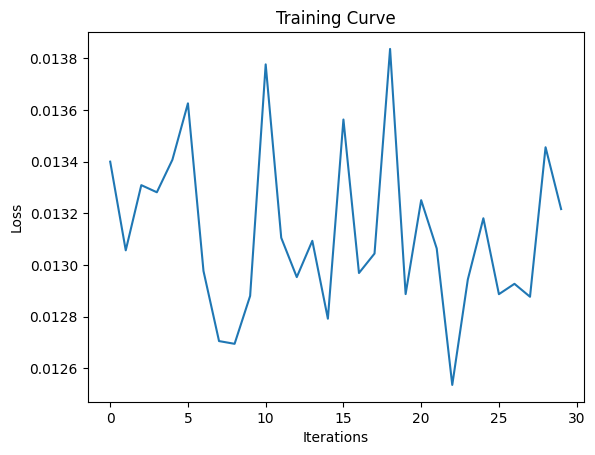

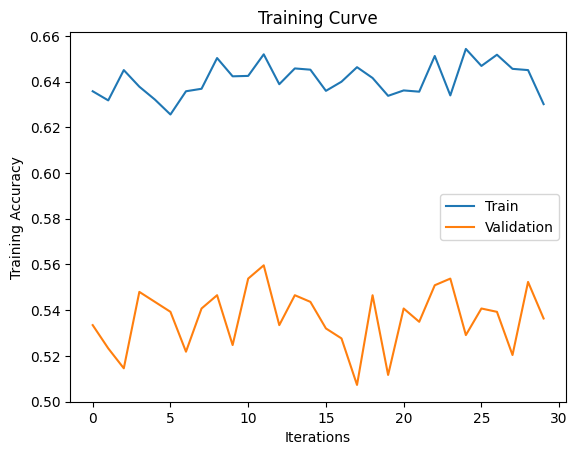

Final Training Accuracy: 0.6301071363718903
Final Validation Accuracy: 0.5363372093023255
Best Training Accuracy: 0.6542582168149628
Best Validation Accuracy: 0.559593023255814
Correct Labels
tensor([ 5, 35,  1, 39, 15,  7,  7], device='cuda:0')
Predicted Labels
[tensor(5), tensor(35), tensor(2), tensor(23), tensor(3), tensor(39), tensor(1)]
Testing


0.5218023255813954

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 270 E

Training
Epoch: 1, Train Accuracy: 0.631560, Validation Accuracy: 0.537791, Time: 1.40 minutes
Epoch: 2, Train Accuracy: 0.641366, Validation Accuracy: 0.529070, Time: 2.80 minutes
Epoch: 3, Train Accuracy: 0.629926, Validation Accuracy: 0.531977, Time: 4.20 minutes
Epoch: 4, Train Accuracy: 0.657890, Validation Accuracy: 0.527616, Time: 5.59 minutes
Epoch: 5, Train Accuracy: 0.612856, Validation Accuracy: 0.529070, Time: 6.98 minutes
Epoch: 6, Train Accuracy: 0.640639, Validation Accuracy: 0.537791, Time: 8.37 minutes
Epoch: 7, Train Accuracy: 0.621936, Validation Accuracy: 0.530523, Time: 9.77 minutes
Epoch: 8, Train Accuracy: 0.645360, Validation Accuracy: 0.542151, Time: 11.15 minutes
Epoch: 9, Train Accuracy: 0.655711, Validation Accuracy: 0.543605, Time: 12.54 minutes
Epoch: 10, Train Accuracy: 0.646995, Validation Accuracy: 0.515988, Time: 13.94 minutes
Epoch: 11, Train Accuracy: 0.659524, Validation Accuracy: 0.530523, Time: 15.32 minutes
Epoch: 12, Train Accuracy: 0.633013, Va

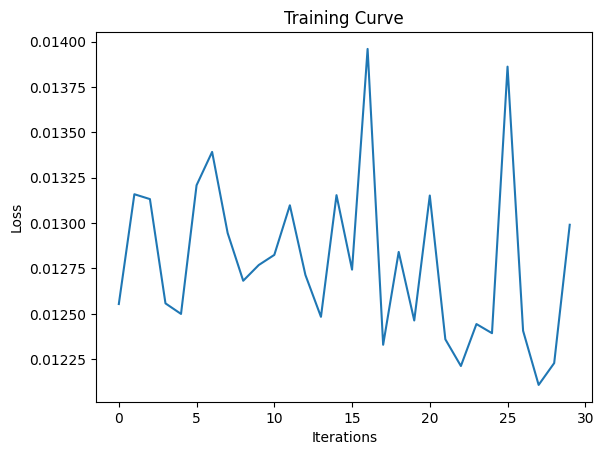

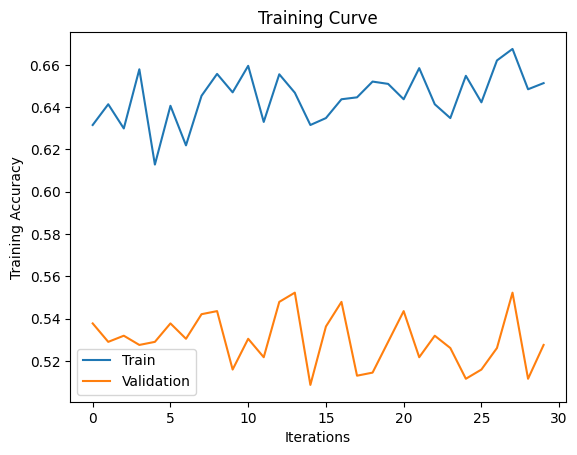

Final Training Accuracy: 0.6513528236789541
Final Validation Accuracy: 0.5276162790697675
Best Training Accuracy: 0.6675140729980026
Best Validation Accuracy: 0.5523255813953488
Correct Labels
tensor([ 9,  9, 35,  0, 38,  1, 34], device='cuda:0')
Predicted Labels
[tensor(24), tensor(4), tensor(35), tensor(38), tensor(38), tensor(7), tensor(15)]
Testing


0.5087209302325582

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 300 E

Training
Epoch: 1, Train Accuracy: 0.646632, Validation Accuracy: 0.526163, Time: 1.41 minutes
Epoch: 2, Train Accuracy: 0.656982, Validation Accuracy: 0.523256, Time: 2.82 minutes
Epoch: 3, Train Accuracy: 0.661159, Validation Accuracy: 0.524709, Time: 4.23 minutes
Epoch: 4, Train Accuracy: 0.654440, Validation Accuracy: 0.515988, Time: 5.71 minutes
Epoch: 5, Train Accuracy: 0.658979, Validation Accuracy: 0.552326, Time: 7.16 minutes
Epoch: 6, Train Accuracy: 0.650263, Validation Accuracy: 0.507267, Time: 8.59 minutes
Epoch: 7, Train Accuracy: 0.659161, Validation Accuracy: 0.537791, Time: 10.00 minutes
Epoch: 8, Train Accuracy: 0.666788, Validation Accuracy: 0.539244, Time: 11.45 minutes
Epoch: 9, Train Accuracy: 0.653532, Validation Accuracy: 0.540698, Time: 12.95 minutes
Epoch: 10, Train Accuracy: 0.653350, Validation Accuracy: 0.556686, Time: 14.39 minutes
Epoch: 11, Train Accuracy: 0.658253, Validation Accuracy: 0.530523, Time: 15.88 minutes
Epoch: 12, Train Accuracy: 0.637734, V

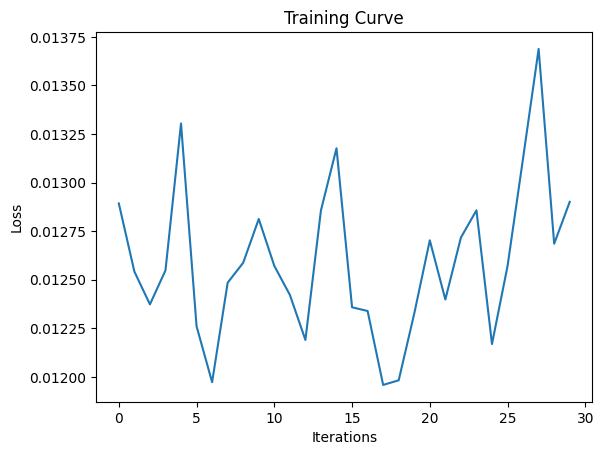

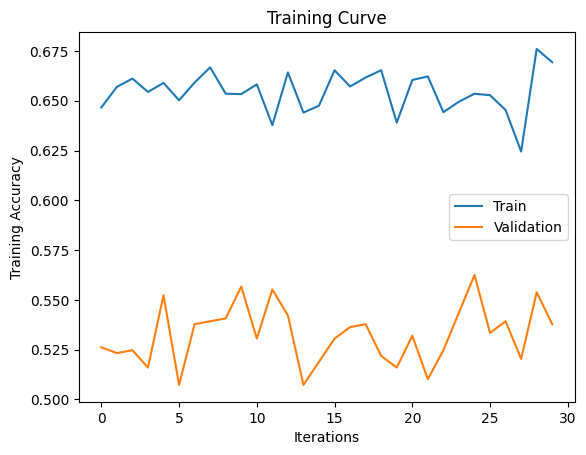

Final Training Accuracy: 0.669329943708008
Final Validation Accuracy: 0.5377906976744186
Best Training Accuracy: 0.6760486653350282
Best Validation Accuracy: 0.5625
Correct Labels
tensor([19, 28, 17, 16, 33, 22,  1], device='cuda:0')
Predicted Labels
[tensor(3), tensor(35), tensor(19), tensor(27), tensor(33), tensor(37), tensor(1)]
Testing


0.5072674418604651

In [ ]:
epoch_n += 30

print("Training")
store_out, store_label = train(model, train_dataset, val_dataset, batch_size=100, num_epochs=30, learningRate=0.001, weight_decay=0.003)

model_save_name = get_model_name("0406_CNN_6", 100, 0.001, epoch_n)
path = F"/content/drive/MyDrive/APS360/Project - Self/Transfer_Weights/{model_save_name}"
torch.save(model.state_dict(), path)

out_index = []
store_out_cpu = store_out.cpu()
for output in range(len(store_out_cpu)):
  out_index.append(torch.argmax(store_out_cpu[output]))
print("Correct Labels")
print(store_label)
print("Predicted Labels")
print(out_index)

print("Testing")
test_loader=DataLoader(test_dataset, 100, shuffle=True, num_workers=2, pin_memory=True)
get_accuracy(model, test_loader)

### 330 E